# Notebook 18 — LISA Scatter Plot: Annual Discharge at L8

**Purpose**: Publication-ready LISA scatter plot for annual discharge (`dis_m3_pyr`) at L8. Variable chosen because it shows all four significant LISA classes clearly — cluster cores (HH/LL) and outliers (HL/LH).

**Method**: Log-canonical (skewness ~41, matching script 12). L8 LISA already in parquet — no weights rebuild needed. Spatial lag reconstructed as `lag_z = local_I / z`.

**Runtime**: All cells fast (no weights computation).

**Inputs**: `public.basin08` dis_m3_pyr values (PostGIS); LISA from `lisa_classifications.parquet`.

**Output**: `docs/char/figures/fig_3_X_lisa_scatterplot_dis_yr_L8.png`

In [1]:
# Cell 1
%matplotlib inline
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path('../../..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scripts.shared.db_utils import db_connect

REPO    = Path('../../..').resolve()
PARQ    = REPO / 'output' / 'edop' / 'esda' / 'lisa_classifications.parquet'
FIG_DIR = REPO / 'docs' / 'char' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

NODATA = -9999

COLOURS = {
    'HH': '#c0392b', 'LL': '#4575b4',
    'LH': '#fdae61', 'HL': '#abd9e9', 'NS': '#bbbbbb',
}

print(f'PARQ exists: {PARQ.exists()}')


PARQ exists: True


In [2]:
# Cell 2 — load dis_m3_pyr from PostGIS + L8 LISA from parquet
print('Loading L8 discharge values from PostGIS...')
t0 = time.time()
conn = db_connect()
with conn.cursor() as cur:
    cur.execute("""
        SELECT hybas_id, dis_m3_pyr
        FROM public.basin08
        ORDER BY hybas_id
    """)
    rows = cur.fetchall()
conn.close()
m, s = divmod(time.time() - t0, 60)
print(f'  fetch [{int(m)}m {s:.0f}s]  n={len(rows):,}')

vals = pd.DataFrame(rows, columns=['hybas_id', 'dis_m3_pyr'])
vals['hybas_id'] = vals['hybas_id'].astype(float)

print('Loading L8 dis_m3_pyr LISA from parquet...')
lisa_df = pd.read_parquet(PARQ)
lisa_df = lisa_df[(lisa_df.variable == 'dis_m3_pyr') & (lisa_df.scale == 'L8')].copy()
print(f'  LISA rows: {len(lisa_df):,}')

df = vals.merge(lisa_df[['hybas_id', 'local_I', 'lisa_class']], on='hybas_id', how='inner')
print(f'  Merged: {len(df):,} basins')

y_raw = df['dis_m3_pyr'].values.astype(float)
y_raw[y_raw == NODATA] = np.nan
y_raw = np.where(np.isnan(y_raw), np.nanmean(y_raw), y_raw)
y_log = np.log1p(np.clip(y_raw, 0, None))

z = (y_log - y_log.mean()) / y_log.std()
with np.errstate(invalid='ignore', divide='ignore'):
    lag_z = np.where(np.abs(z) > 1e-10, df['local_I'].values / z, np.nan)

df['z']     = z
df['lag_z'] = lag_z

counts = df['lisa_class'].value_counts().reindex(['HH','LL','HL','LH','NS'], fill_value=0)
n = len(df)
print('\nL8 dis_m3_pyr LISA class distribution:')
for cls, cnt in counts.items():
    print(f'  {cls}: {cnt:5,}  ({cnt/n*100:.1f}%)')
print('\nExpected from variable_characterization.csv: HH=15.6%, LL=23.5%, HL=0.3%, LH=3.5%')


  LISA rows: 190,675
  Merged: 190,675 basins

L8 dis_m3_pyr LISA class distribution:
  HH: 29,819  (15.6%)
  LL: 44,890  (23.5%)
  HL:   626  (0.3%)
  LH: 6,752  (3.5%)
  NS: 108,588  (56.9%)

Expected from variable_characterization.csv: HH=15.6%, LL=23.5%, HL=0.3%, LH=3.5%


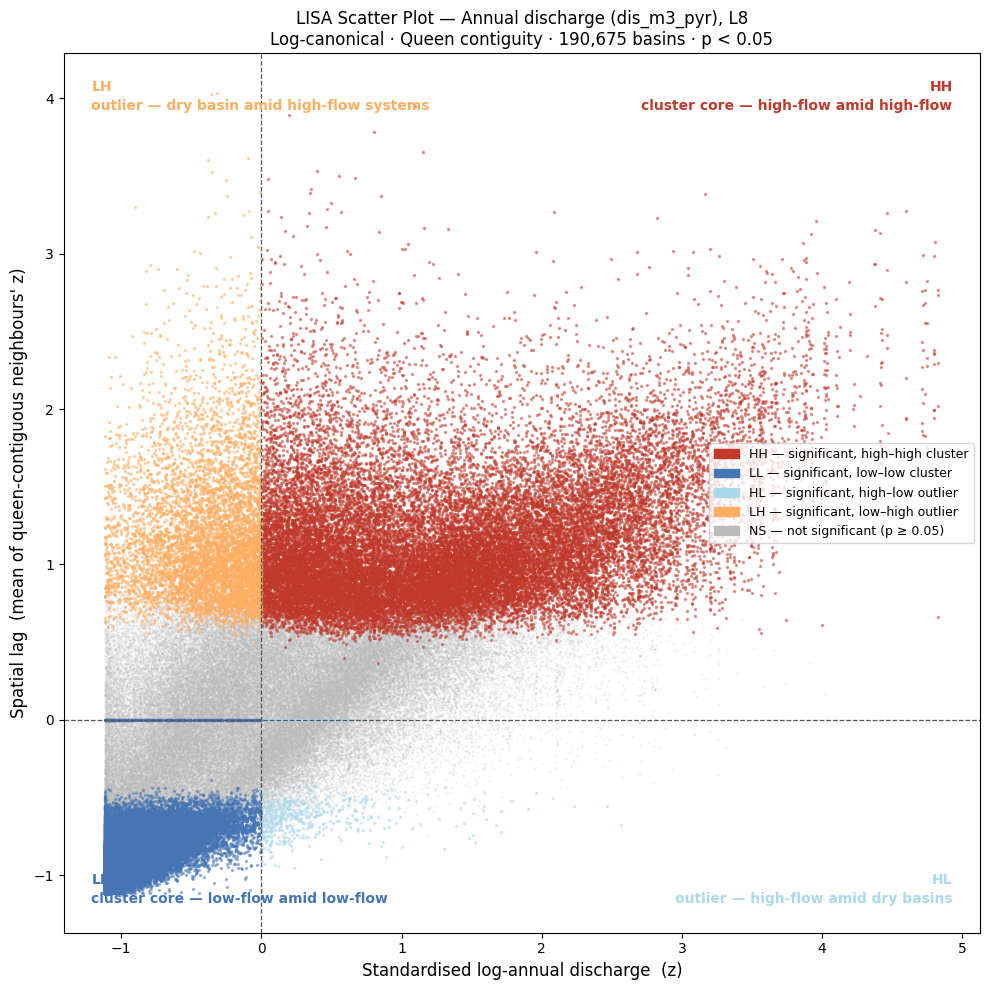

In [3]:
# Cell 3 — render LISA scatter plot
plt.rcParams.update({
    "text.color": "black", "axes.labelcolor": "black",
    "xtick.color": "black", "ytick.color": "black",
    "axes.edgecolor": "black", "figure.facecolor": "white",
    "axes.facecolor": "white",
})
valid = df.dropna(subset=['lag_z'])
print(f'Plotting {len(valid):,} basins  (z\u22480 excluded: {len(df)-len(valid)})')

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for cls in ['NS', 'LL', 'HH', 'HL', 'LH']:
    sub = valid[valid.lisa_class == cls]
    ax.scatter(sub['z'], sub['lag_z'],
               s=0.5 if cls == 'NS' else 2.0,
               alpha=0.15 if cls == 'NS' else 0.45,
               color=COLOURS[cls], rasterized=True)

ax.axhline(0, color='#555555', linewidth=0.9, linestyle='--')
ax.axvline(0, color='#555555', linewidth=0.9, linestyle='--')

quad_labels = {
    'HH': (0.97, 0.97, 'right', 'top',   'HH\ncluster core \u2014 high-flow amid high-flow'),
    'LL': (0.03, 0.03, 'left',  'bottom', 'LL\ncluster core \u2014 low-flow amid low-flow'),
    'LH': (0.03, 0.97, 'left',  'top',    'LH\noutlier \u2014 dry basin amid high-flow systems'),
    'HL': (0.97, 0.03, 'right', 'bottom', 'HL\noutlier \u2014 high-flow amid dry basins'),
}
for cls, (x, y, ha, va, label) in quad_labels.items():
    ax.text(x, y, label, transform=ax.transAxes,
            ha=ha, va=va, fontsize=10, fontweight='bold',
            color=COLOURS[cls], linespacing=1.5)

ax.set_xlabel('Standardised log-annual discharge  (z)', fontsize=12)
ax.set_ylabel("Spatial lag  (mean of queen-contiguous neighbours' z)", fontsize=12)
ax.set_title(
    'LISA Scatter Plot \u2014 Annual discharge (dis_m3_pyr), L8\n'
    'Log-canonical \u00b7 Queen contiguity \u00b7 190,675 basins \u00b7 p < 0.05',
    fontsize=12)

ax.legend(handles=[
    mpatches.Patch(color=COLOURS['HH'], label='HH \u2014 significant, high\u2013high cluster'),
    mpatches.Patch(color=COLOURS['LL'], label='LL \u2014 significant, low\u2013low cluster'),
    mpatches.Patch(color=COLOURS['HL'], label='HL \u2014 significant, high\u2013low outlier'),
    mpatches.Patch(color=COLOURS['LH'], label='LH \u2014 significant, low\u2013high outlier'),
    mpatches.Patch(color=COLOURS['NS'], label='NS \u2014 not significant (p \u2265 0.05)'),
], loc='center right', fontsize=9, framealpha=0.8)

plt.tight_layout()
out = FIG_DIR / 'fig_3_X_lisa_scatterplot_dis_yr_L8.png'
fig.savefig(out, dpi=120, bbox_inches='tight', transparent=False)
print(f'Saved \u2192 {out}')


## Findings

*Fill in after running.*

### F18.1 — L8 dis_m3_pyr LISA class counts
<!-- from Cell 2 — verify against variable_characterization.csv: HH=15.6%, LL=23.5%, HL=0.3%, LH=3.5% -->

### F18.2 — Figure
<!-- visibility of all four LISA classes, particularly LH outlier arm (watershed-divide effect) -->